# Nuclearity Prediction from CSD PDF-based descriptors

This notebook applies the analysis to **real CSD (Cambridge Structural Database) structure PDFs** to validate whether the simple feature-based approach generalizes beyond synthetic cluster data.

**Key Question**: Do peak intensity ratios work as well on real crystallographic structures as they do on synthetic Th clusters?

**Dataset**: CSD structure calculated PDFs (~700 diverse structures)

**Classes**: 10 total (nuclearities 1-9 + polymer class labeled as 10)

In [1]:
import os
import matplotlib.pyplot as plt
import glob
import pandas as pd
import numpy as np
from numpy import trapz
import sys
from pathlib import Path

# Add parent directory to path for config import
sys.path.insert(0, '../..')
from config import get_path, setup_workdir

## Dataset Overview

Let's look at the distribution of nuclearities in the CSD dataset.

Working directory: /Volumes/Extreme SSD/PDF NN/pdf-nn-data/csd_structures/calculated_pdfs
Total CSD structures: 645
Nuclearity distribution: {'1': 70, '2': 166, '3': 6, '4': 99, '5': 7, '6': 22, '7': 14, '8': 17, '9': 30, '10': 214}


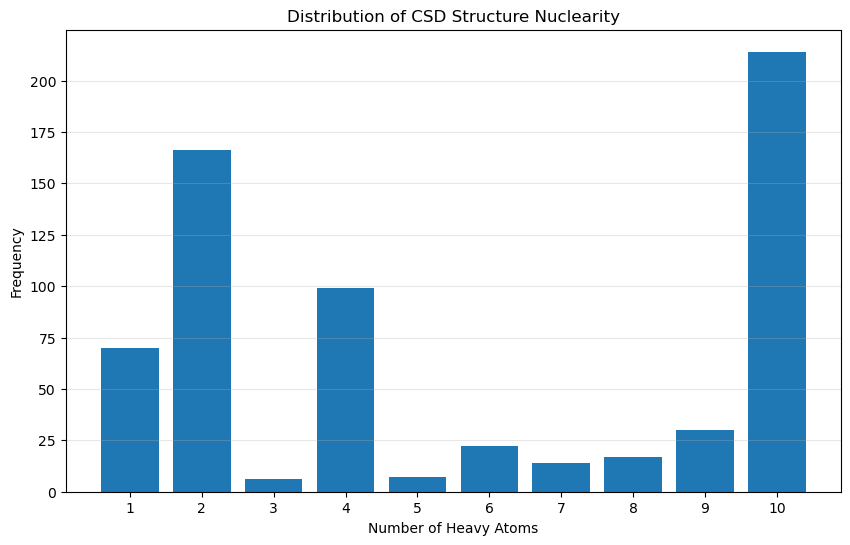

In [2]:
# Set working directory and paths using config
setup_workdir('csd_calculated_pdfs')
labels_path = get_path('labels') / 'csd_labels.txt'

def read_txt_file(filename):
    with open(filename, 'r') as file:
        lines = file.readlines()
    return [int(line.strip()) for line in lines]

def count_occurrences(numbers):
    count_dict = {str(i): 0 for i in range(1, 11)}  # Include 10 for polymers
    for number in numbers:
        if 1 <= number <= 10:  # Include polymer class (10)
            count_dict[str(number)] += 1
    return count_dict

def plot_bar_chart(count_dict):
    numbers = list(count_dict.keys())
    counts = list(count_dict.values())

    plt.figure(figsize=(10, 6))
    plt.bar(numbers, counts)
    plt.xlabel('Number of Heavy Atoms')
    plt.ylabel('Frequency')
    plt.title('Distribution of CSD Structure Nuclearity')
    plt.grid(True, alpha=0.3, axis='y')
    plt.show()

numbers = read_txt_file(labels_path)
count_dict = count_occurrences(numbers)
print(f"Total CSD structures: {len(numbers)}")
print(f"Nuclearity distribution: {count_dict}")
plot_bar_chart(count_dict)

## Feature Extraction from CSD PDF Files

Extract the same 20 comprehensive features from CSD structure PDFs:
- Peak areas and intensity ratios
- Peak positions and heights
- Coordination shell integrals
- PDF moments

CSD PDF files directory: /Users/dimitrygrebenyuk/Documents/GitHub/PDF-NN/complete workflow/pdf-nn-data/csd_structures/calculated_pdfs
Feature output directory: /Users/dimitrygrebenyuk/Documents/GitHub/PDF-NN/complete workflow/pdf-nn-data/csd_structures/pdf_features
Found 645 CSD PDF files to process


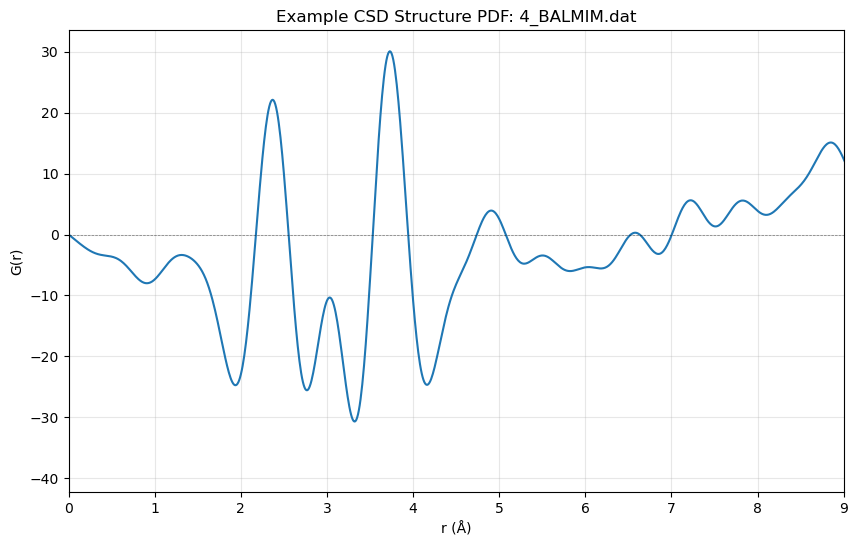

In [3]:
# Setup directories for CSD data
pdf_dir = get_path('csd_calculated_pdfs')
csd_features_dir = get_path('csd_structures') / 'pdf_features'
csd_features_dir.mkdir(parents=True, exist_ok=True)

print(f"CSD PDF files directory: {pdf_dir}")
print(f"Feature output directory: {csd_features_dir}")

files_pdf = list(pdf_dir.glob('*.dat'))
print(f"Found {len(files_pdf)} CSD PDF files to process")

# Plot example CSD PDF
if len(files_pdf) > 0:
    example_file = files_pdf[0]
    data = pd.read_csv(example_file, skiprows=1, delim_whitespace=True, index_col=False)
    data.columns = ['r', 'g']
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(data.r, data.g, linewidth=1.5)
    ax.set_xlim(0, 9)
    ax.set_xlabel('r (Å)')
    ax.set_ylabel('G(r)')
    ax.set_title(f'Example CSD Structure PDF: {example_file.name}')
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5, alpha=0.5)
    plt.show()

In [4]:
# Enhanced feature extraction from CSD PDF files
features_path = csd_features_dir / 'csd_pdf_features.txt'

print(f"Extracting features from {len(files_pdf)} CSD PDF files...")

def extract_pdf_features(df):
    """Extract comprehensive PDF features for classification"""
    features = {}
    
    # Define peak regions (same as cluster analysis for consistency)
    peak1_mask = (df['r'] >= 2.0) & (df['r'] <= 3.0)
    peak2_mask = (df['r'] >= 3.5) & (df['r'] <= 4.2) 
    peak3_mask = (df['r'] >= 6.0) & (df['r'] <= 7.0)
    
    peak1 = df.loc[peak1_mask]
    peak2 = df.loc[peak2_mask]
    peak3 = df.loc[peak3_mask]
    
    # Peak areas (integrals of G(r))
    area1 = trapz(peak1.g, peak1.r) if len(peak1) > 0 else 0
    area2 = trapz(peak2.g, peak2.r) if len(peak2) > 0 else 0
    area3 = trapz(peak3.g, peak3.r) if len(peak3) > 0 else 0
    
    features['area1'] = area1
    features['area2'] = area2  
    features['area3'] = area3
    
    # Peak intensity ratios
    features['ratio_21'] = area2/area1 if area1 > 0 else 0
    features['ratio_23'] = area2/area3 if area3 > 0 else 0
    features['ratio_31'] = area3/area1 if area1 > 0 else 0
    
    # Peak positions (r-values at maximum intensity)
    features['peak1_pos'] = peak1.loc[peak1.g.idxmax(), 'r'] if len(peak1) > 0 and peak1.g.max() > 0 else 2.5
    features['peak2_pos'] = peak2.loc[peak2.g.idxmax(), 'r'] if len(peak2) > 0 and peak2.g.max() > 0 else 3.85
    features['peak3_pos'] = peak3.loc[peak3.g.idxmax(), 'r'] if len(peak3) > 0 and peak3.g.max() > 0 else 6.5
    
    # Peak heights (maximum intensities)
    features['peak1_height'] = peak1.g.max() if len(peak1) > 0 else 0
    features['peak2_height'] = peak2.g.max() if len(peak2) > 0 else 0
    features['peak3_height'] = peak3.g.max() if len(peak3) > 0 else 0
    
    # Peak height ratios
    features['height_21'] = features['peak2_height']/features['peak1_height'] if features['peak1_height'] > 0 else 0
    features['height_31'] = features['peak3_height']/features['peak1_height'] if features['peak1_height'] > 0 else 0
    
    # Coordination shell integrals (broader regions)
    shell1_mask = (df['r'] >= 1.5) & (df['r'] <= 3.5)
    shell2_mask = (df['r'] >= 3.0) & (df['r'] <= 5.0)
    shell3_mask = (df['r'] >= 5.5) & (df['r'] <= 7.5)
    
    features['shell1_coord'] = trapz(df.loc[shell1_mask, 'g'], df.loc[shell1_mask, 'r']) if shell1_mask.any() else 0
    features['shell2_coord'] = trapz(df.loc[shell2_mask, 'g'], df.loc[shell2_mask, 'r']) if shell2_mask.any() else 0
    features['shell3_coord'] = trapz(df.loc[shell3_mask, 'g'], df.loc[shell3_mask, 'r']) if shell3_mask.any() else 0
    
    # PDF moments and shape descriptors
    r_vals = df['r'].values
    g_vals = df['g'].values
    
    # For PDF, handle negative values by using positive part only
    g_pos = np.maximum(g_vals, 0)
    
    # First moment (weighted average r-position of positive peaks)
    if np.sum(g_pos) > 0:
        features['moment1'] = np.sum(r_vals * g_pos) / np.sum(g_pos)
        features['moment2'] = np.sum((r_vals - features['moment1'])**2 * g_pos) / np.sum(g_pos)
    else:
        features['moment1'] = 0
        features['moment2'] = 0
    
    # Total PDF integral (0-10 Å)
    total_mask = (df['r'] >= 0) & (df['r'] <= 10)
    features['total_integral'] = trapz(df.loc[total_mask, 'g'], df.loc[total_mask, 'r']) if total_mask.any() else 0
    
    return features

# Load CSD labels
csd_labels = read_txt_file(labels_path)
print(f"Loaded {len(csd_labels)} CSD labels")

# Create label lookup by filename index
label_lookup = {i: label for i, label in enumerate(csd_labels)}

# Extract features from all CSD PDF files
all_features = []
with open(features_path, 'w') as f:
    # Write header
    feature_names = ['nuclearity', 'area1', 'area2', 'area3', 'ratio_21', 'ratio_23', 'ratio_31',
                     'peak1_pos', 'peak2_pos', 'peak3_pos', 'peak1_height', 'peak2_height', 'peak3_height',
                     'height_21', 'height_31', 'shell1_coord', 'shell2_coord', 'shell3_coord', 
                     'moment1', 'moment2', 'total_integral']
    f.write(' '.join(feature_names) + '\n')
    
    for i, file_path in enumerate(sorted(files_pdf)):
        try:
            # Load PDF data
            data = pd.read_csv(file_path, skiprows=1, delim_whitespace=True, index_col=False)
            data.columns = ['r', 'g']
            
            # Extract features
            features = extract_pdf_features(data)
            
            # Get nuclearity from label file (by index)
            if i < len(csd_labels):
                nuclearity = csd_labels[i]
            else:
                print(f"Warning: No label for file {i}: {file_path.name}")
                continue
            
            # Only include valid nuclearities (1-10, where 10 = polymer)
            if not (1 <= nuclearity <= 10):
                continue
            
            # Write to file
            feature_row = [nuclearity] + [features[name] for name in feature_names[1:]]
            f.write(' '.join(map(str, feature_row)) + '\n')
            all_features.append(feature_row)
            
        except Exception as e:
            print(f"Error processing {file_path.name}: {e}")
            continue
            
        if i % 100 == 0:
            print(f"Extracted features from {i} files...")

print(f"Feature extraction complete")
print(f"  Features saved to: {features_path}")
print(f"  Total samples with valid nuclearity: {len(all_features)}")
print(f"  Total features per sample: {len(feature_names)-1}")

Extracting features from 645 CSD PDF files...
Loaded 645 CSD labels
Extracted features from 0 files...
Extracted features from 100 files...
Extracted features from 200 files...
Extracted features from 300 files...
Extracted features from 400 files...
Extracted features from 500 files...
Extracted features from 600 files...
Feature extraction complete
  Features saved to: /Users/dimitrygrebenyuk/Documents/GitHub/PDF-NN/complete workflow/pdf-nn-data/csd_structures/pdf_features/csd_pdf_features.txt
  Total samples with valid nuclearity: 645
  Total features per sample: 20


## Data Visualization

Visualize CSD PDF features and compare with synthetic cluster data.

Loaded 645 CSD samples with 20 features


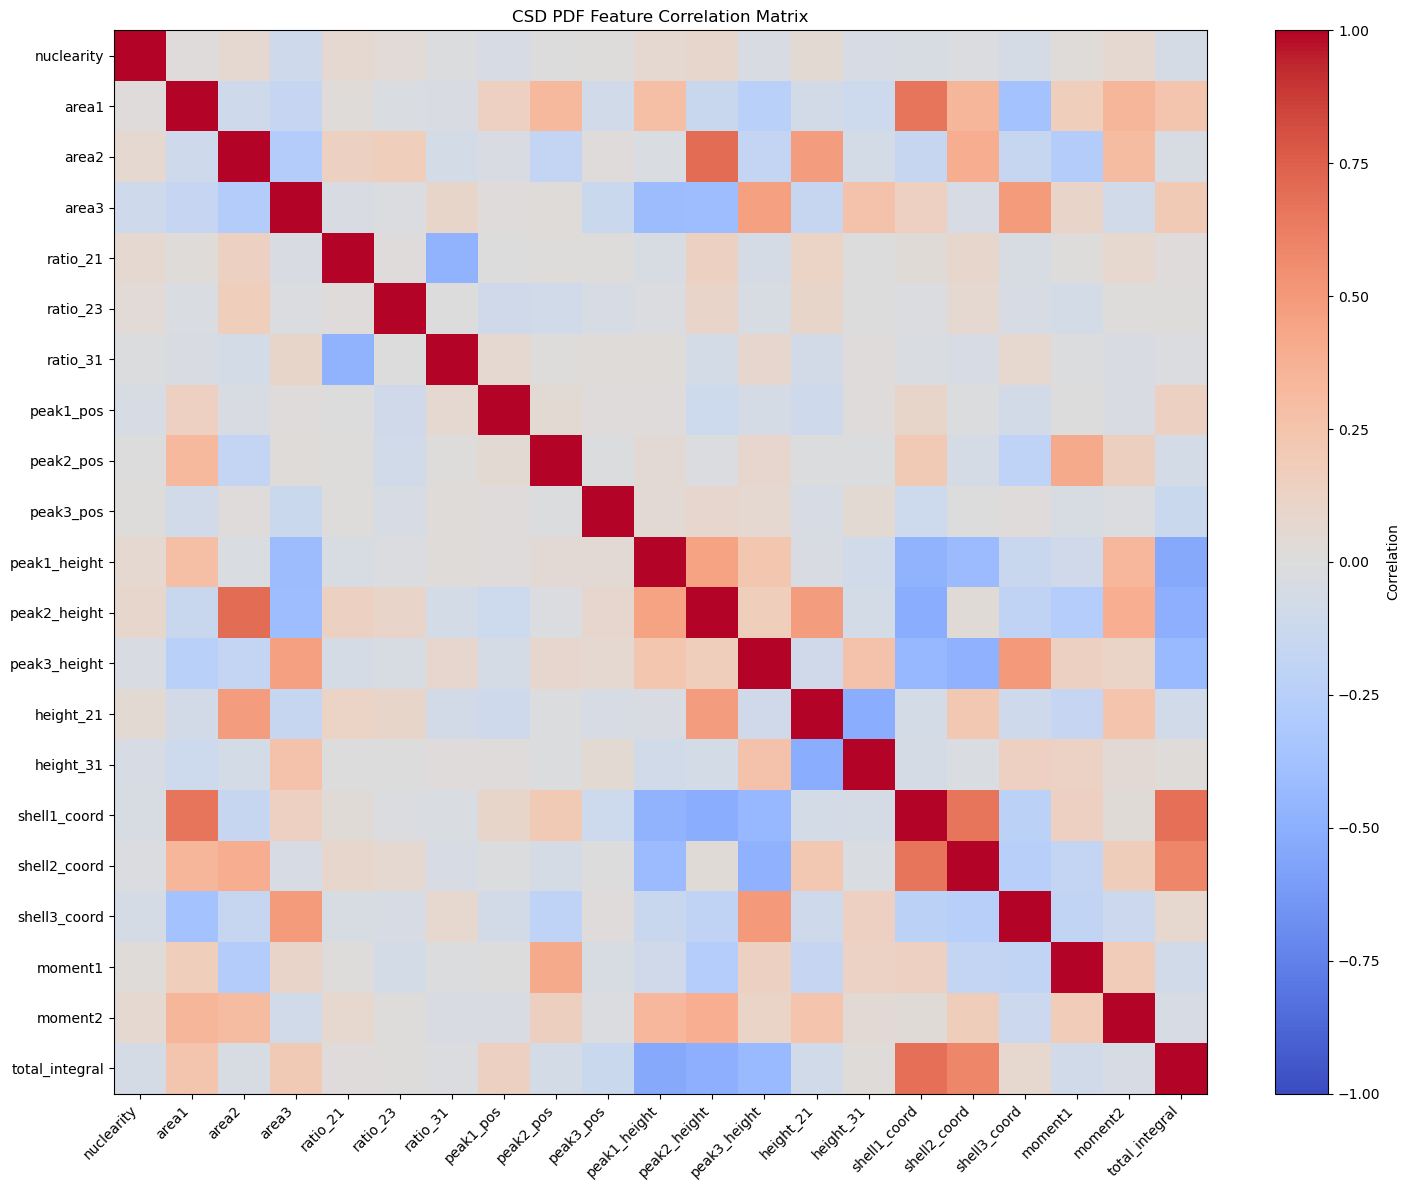

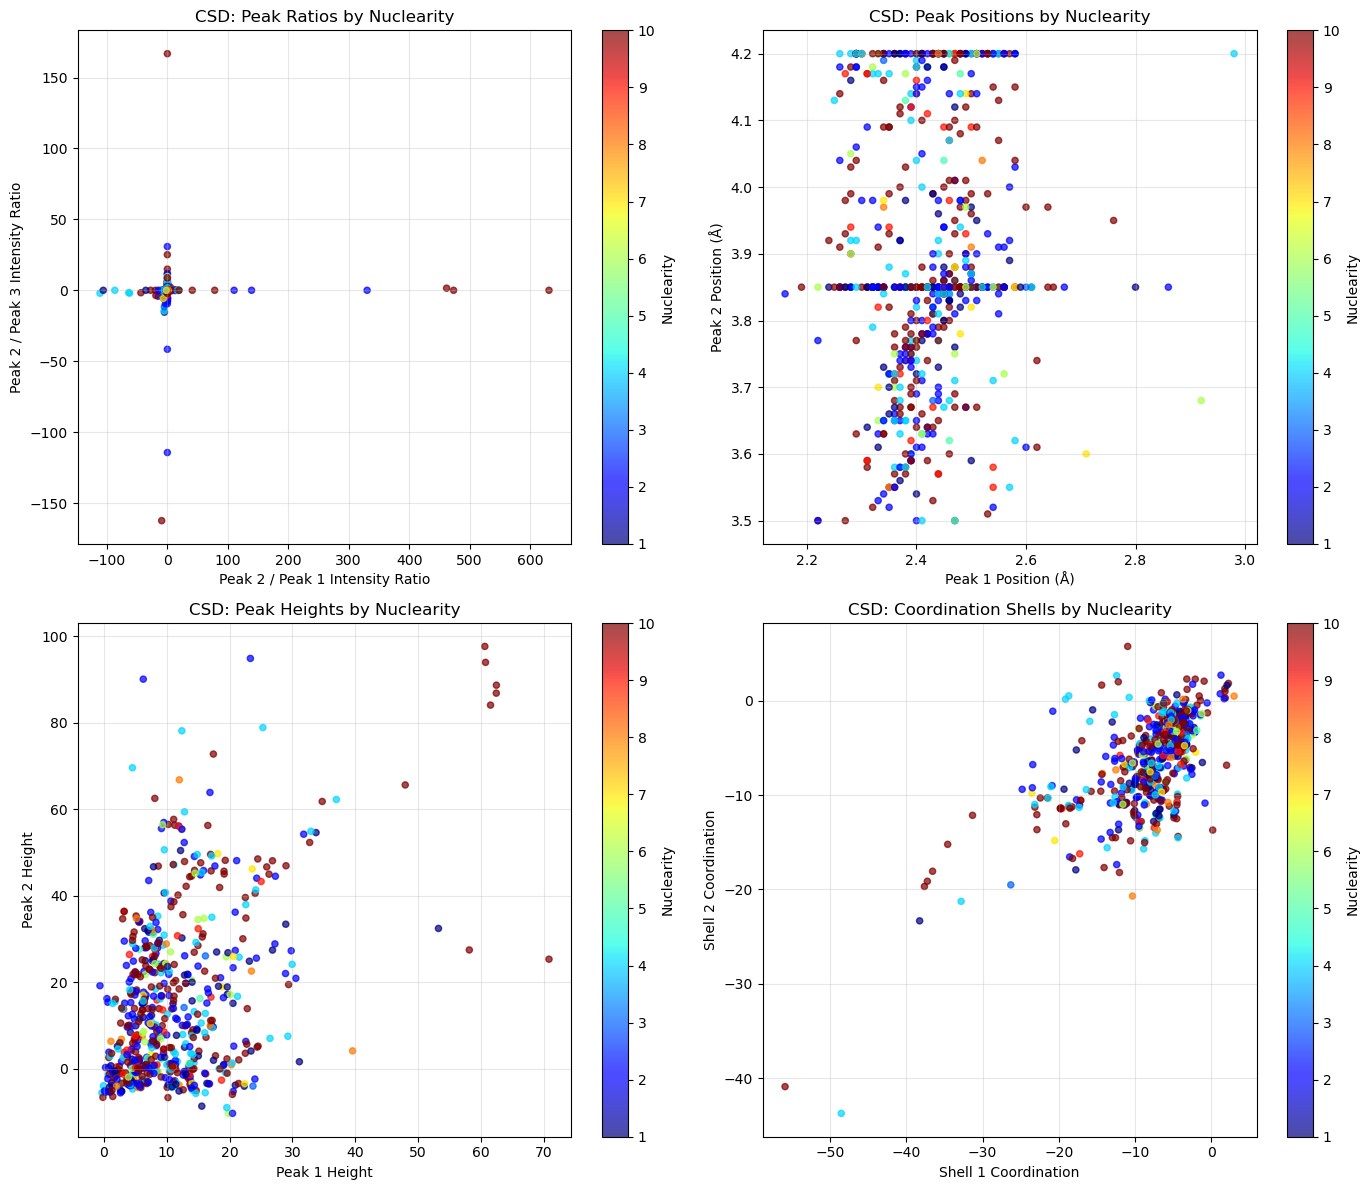


CSD Feature statistics:
       nuclearity    area1    area2    area3  ratio_21  ratio_23  ratio_31  \
count     645.000  645.000  645.000  645.000   645.000   645.000   645.000   
mean        5.623   -0.779   -0.348   -1.082     2.551    -0.326    -2.274   
std         3.643    2.345    4.864    3.823    39.989    10.660    28.101   
min         1.000  -13.046  -12.510  -16.909  -111.467  -162.387  -545.573   
25%         2.000   -1.868   -3.869   -2.678     0.000     0.000     0.000   
50%         4.000   -0.792   -0.961   -1.199     0.000     0.000     0.000   
75%        10.000    0.301    2.577   -0.075     0.000     0.000     0.000   
max        10.000   14.912   24.736   20.073   631.276   166.810   307.876   

       peak1_pos  peak2_pos  peak3_pos  ...  peak2_height  peak3_height  \
count    645.000    645.000    645.000  ...       645.000       645.000   
mean       2.421      3.900      6.541  ...        15.213         8.652   
std        0.093      0.197      0.320  ...    

In [12]:
# Load and visualize CSD PDF features
features_data = pd.read_csv(features_path, delim_whitespace=True, header=0, index_col=False)
print(f"Loaded {len(features_data)} CSD samples with {len(feature_names)-1} features")

# Visualize feature correlations
plt.figure(figsize=(15, 12))
correlation_matrix = features_data.corr()
plt.imshow(correlation_matrix, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
plt.colorbar(label='Correlation')
plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha='right')
plt.yticks(range(len(feature_names)), feature_names)
plt.title('CSD PDF Feature Correlation Matrix')
plt.tight_layout()
plt.show()

# Create scatter plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Peak ratios
scatter1 = axes[0, 0].scatter(features_data['ratio_21'], features_data['ratio_23'], 
                              c=features_data['nuclearity'], cmap='jet', s=20, alpha=0.7)
axes[0, 0].set_xlabel('Peak 2 / Peak 1 Intensity Ratio')
axes[0, 0].set_ylabel('Peak 2 / Peak 3 Intensity Ratio')
axes[0, 0].set_title('CSD: Peak Ratios by Nuclearity')
plt.colorbar(scatter1, ax=axes[0, 0], label='Nuclearity')
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Peak positions
scatter2 = axes[0, 1].scatter(features_data['peak1_pos'], features_data['peak2_pos'], 
                              c=features_data['nuclearity'], cmap='jet', s=20, alpha=0.7)
axes[0, 1].set_xlabel('Peak 1 Position (Å)')
axes[0, 1].set_ylabel('Peak 2 Position (Å)')
axes[0, 1].set_title('CSD: Peak Positions by Nuclearity')
plt.colorbar(scatter2, ax=axes[0, 1], label='Nuclearity')
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Peak heights
scatter3 = axes[1, 0].scatter(features_data['peak1_height'], features_data['peak2_height'], 
                              c=features_data['nuclearity'], cmap='jet', s=20, alpha=0.7)
axes[1, 0].set_xlabel('Peak 1 Height')
axes[1, 0].set_ylabel('Peak 2 Height')
axes[1, 0].set_title('CSD: Peak Heights by Nuclearity')
plt.colorbar(scatter3, ax=axes[1, 0], label='Nuclearity')
axes[1, 0].grid(True, alpha=0.3)

# Plot 4: Coordination shells
scatter4 = axes[1, 1].scatter(features_data['shell1_coord'], features_data['shell2_coord'], 
                              c=features_data['nuclearity'], cmap='jet', s=20, alpha=0.7)
axes[1, 1].set_xlabel('Shell 1 Coordination')
axes[1, 1].set_ylabel('Shell 2 Coordination')
axes[1, 1].set_title('CSD: Coordination Shells by Nuclearity')
plt.colorbar(scatter4, ax=axes[1, 1], label='Nuclearity')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Display feature statistics
print("\nCSD Feature statistics:")
print(features_data.describe().round(3))

## Model Training: Gradient Boosting Classifier

Feature matrix shape: (645, 20)
Number of samples: 645
Unique classes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Training samples: 516
Test samples: 129

Training Gradient Boosting Classifier on CSD PDF features...

Gradient Boosting Classification Results (CSD PDF features):
Accuracy: 0.217
F1-score (weighted): 0.210
F1-score (macro): 0.081

Detailed Classification Report:
              precision    recall  f1-score   support

           1       0.06      0.07      0.07        14
           2       0.30      0.24      0.27        33
           3       0.00      0.00      0.00         1
           4       0.12      0.15      0.14        20
           5       0.00      0.00      0.00         2
           6       0.00      0.00      0.00         4
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00         6
          10       0.31      0.37      0.34        43

    accuracy                        

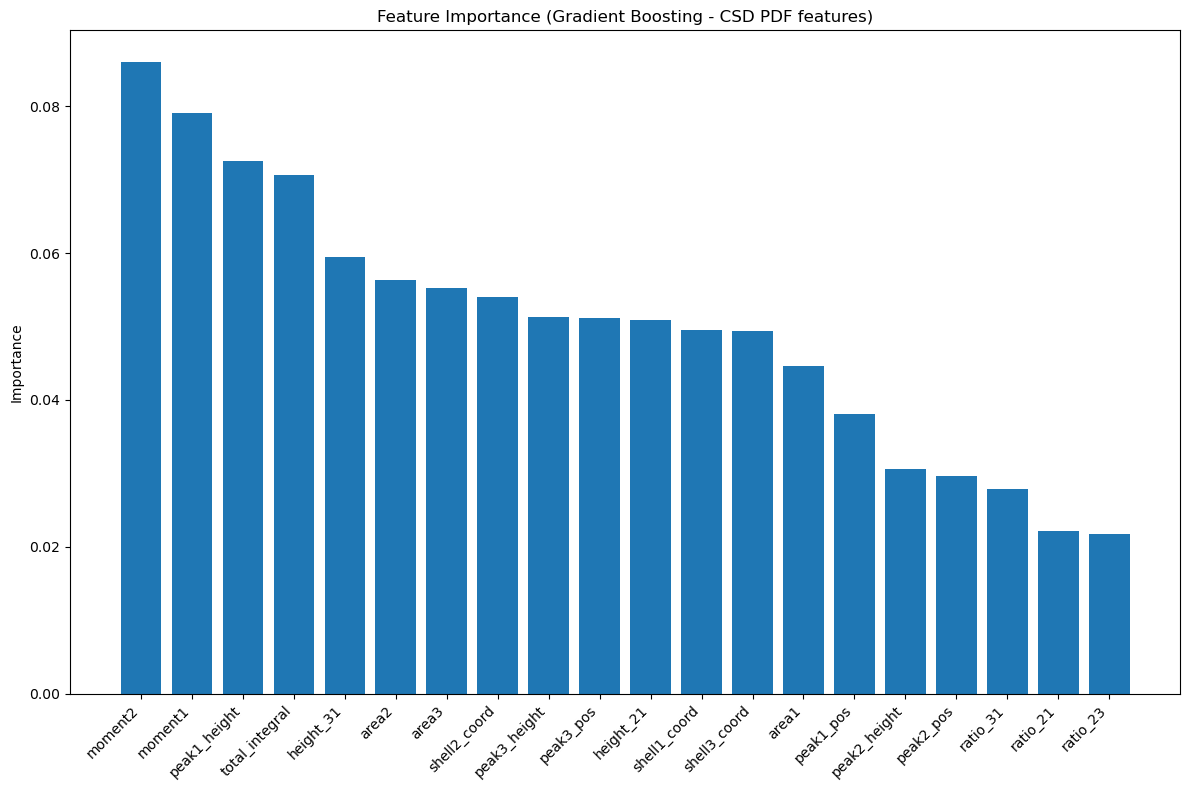


Top 10 most important CSD PDF features:
 1. moment2             : 0.086
 2. moment1             : 0.079
 3. peak1_height        : 0.073
 4. total_integral      : 0.071
 5. height_31           : 0.059
 6. area2               : 0.056
 7. area3               : 0.055
 8. shell2_coord        : 0.054
 9. peak3_height        : 0.051
10. peak3_pos           : 0.051


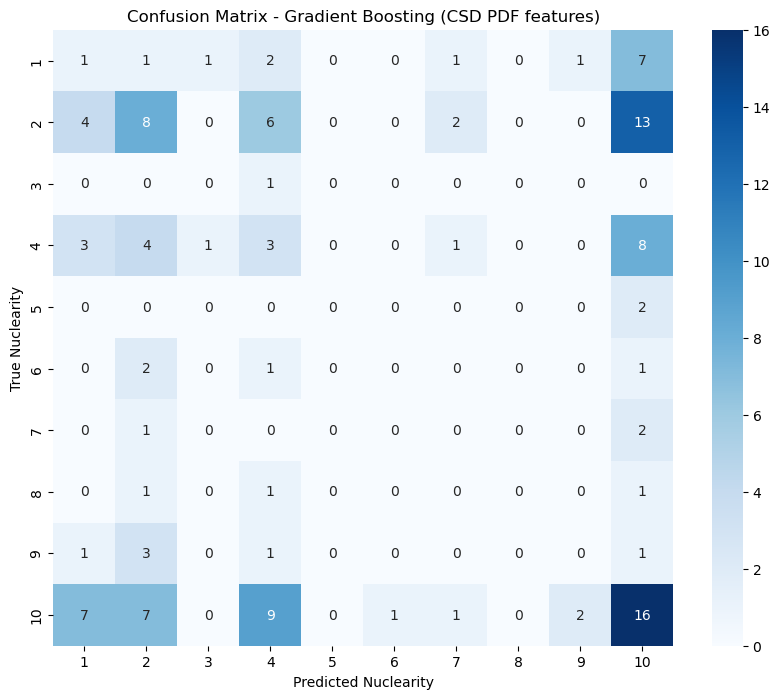

In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for classification
X = features_data.drop('nuclearity', axis=1).values
y = features_data['nuclearity'].values

print(f"Feature matrix shape: {X.shape}")
print(f"Number of samples: {len(y)}")
print(f"Unique classes: {sorted(np.unique(y))}")

# Check if we have enough samples for train/test split
if len(y) < 50:
    print(f"\nWARNING: Only {len(y)} samples available. Results may not be reliable.")
    print("Consider using cross-validation only or gathering more data.")

# Split the data into training and testing sets
test_size = 0.2 if len(y) >= 50 else 0.3
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=42, stratify=y)

print(f"\nTraining samples: {len(y_train)}")
print(f"Test samples: {len(y_test)}")

# Scale features for better performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Create and train Gradient Boosting Classifier
gb_classifier = GradientBoostingClassifier(
    n_estimators=300, 
    learning_rate=0.1, 
    max_depth=4,  # Reduced depth for smaller dataset
    random_state=42
)

print("\nTraining Gradient Boosting Classifier on CSD PDF features...")
gb_classifier.fit(X_train_scaled, y_train)

# Make predictions
y_pred = gb_classifier.predict(X_test_scaled)

# Calculate classification metrics
accuracy = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
f1_macro = f1_score(y_test, y_pred, average='macro', zero_division=0)

print(f"\n" + "="*70)
print("Gradient Boosting Classification Results (CSD PDF features):")
print("="*70)
print(f"Accuracy: {accuracy:.3f}")
print(f"F1-score (weighted): {f1_weighted:.3f}")
print(f"F1-score (macro): {f1_macro:.3f}")

# Detailed classification report
print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

# Cross-validation performance
cv_folds = min(5, len(np.unique(y_train)))  # Adjust CV folds based on smallest class
cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=42)
cv_scores = cross_val_score(gb_classifier, X_train_scaled, y_train, cv=cv, scoring='f1_weighted')
print(f"\nCross-validation F1-scores ({cv_folds}-fold): {cv_scores}")
print(f"Mean CV F1-score: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")

# Feature importance
feature_importance = gb_classifier.feature_importances_
feature_names_clean = feature_names[1:]  # Remove 'nuclearity'

plt.figure(figsize=(12, 8))
indices = np.argsort(feature_importance)[::-1]
plt.bar(range(len(feature_importance)), feature_importance[indices])
plt.xticks(range(len(feature_importance)), [feature_names_clean[i] for i in indices], rotation=45, ha='right')
plt.title('Feature Importance (Gradient Boosting - CSD PDF features)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print(f"\nTop 10 most important CSD PDF features:")
for i in range(min(10, len(feature_importance))):
    idx = indices[i]
    print(f"{i+1:2d}. {feature_names_clean[idx]:<20s}: {feature_importance[idx]:.3f}")

# Confusion matrix
plt.figure(figsize=(10, 8))
conf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', 
            xticklabels=sorted(np.unique(y)), yticklabels=sorted(np.unique(y)))
plt.xlabel('Predicted Nuclearity')
plt.ylabel('True Nuclearity')
plt.title('Confusion Matrix - Gradient Boosting (CSD PDF features)')
plt.show()

## Model Training: Random Forest Classifier

Training Random Forest Classifier on CSD data...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best parameters: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 0.261

Random Forest Classification Results (CSD):
Accuracy: 0.209
F1-score (weighted): 0.196
F1-score (macro): 0.076

Detailed Classification Report:
              precision    recall  f1-score   support

           1       0.07      0.07      0.07        14
           2       0.30      0.30      0.30        33
           3       0.00      0.00      0.00         1
           4       0.09      0.10      0.10        20
           5       0.00      0.00      0.00         2
           6       0.00      0.00      0.00         4
           7       0.00      0.00      0.00         3
           8       0.00      0.00      0.00         3
           9       0.00      0.00      0.00         6
          10       0.26      0.33      0.29        43


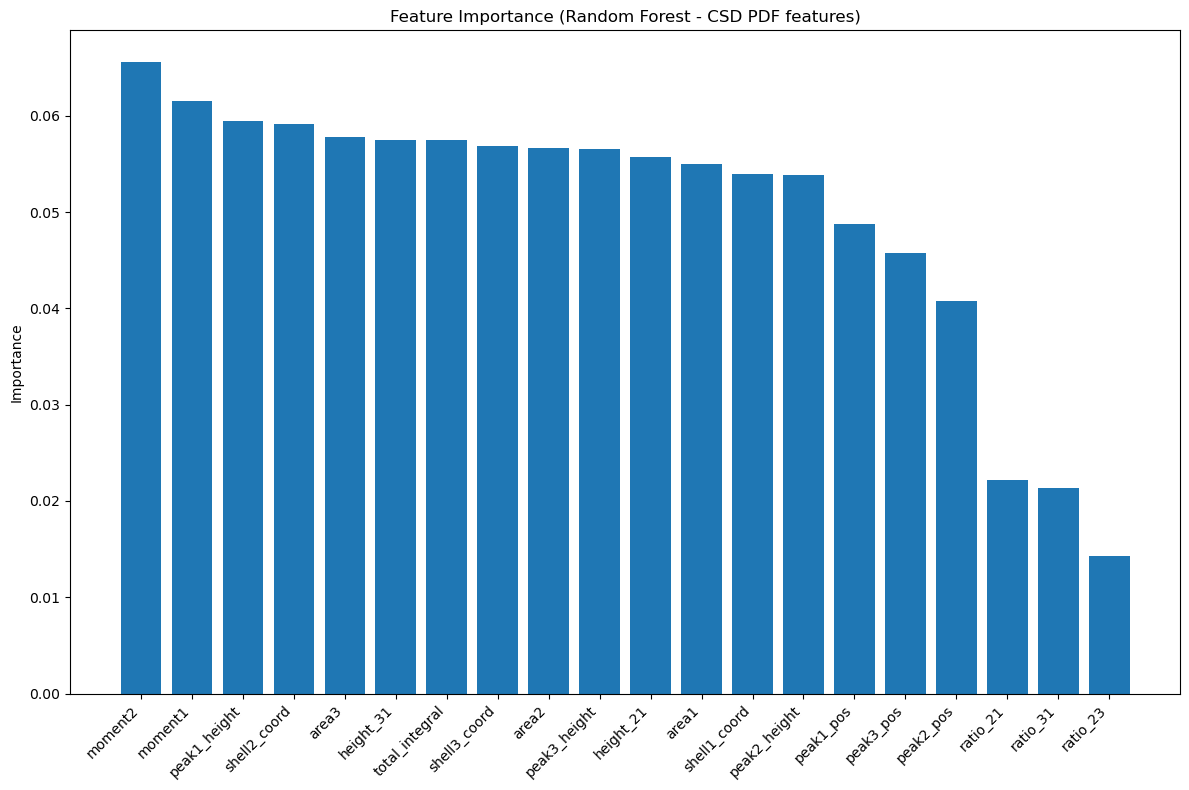


Top 10 most important features (Random Forest):
 1. moment2             : 0.066
 2. moment1             : 0.062
 3. peak1_height        : 0.059
 4. shell2_coord        : 0.059
 5. area3               : 0.058
 6. height_31           : 0.057
 7. total_integral      : 0.057
 8. shell3_coord        : 0.057
 9. area2               : 0.057
10. peak3_height        : 0.057


In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

print("Training Random Forest Classifier on CSD data...")

# Simplified parameter grid for smaller dataset
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

rf_classifier = RandomForestClassifier(random_state=42)

# Adjust CV folds for grid search
cv_folds = min(3, len(np.unique(y_train)))
grid_search = GridSearchCV(
    rf_classifier, 
    param_grid, 
    cv=cv_folds, 
    scoring='f1_weighted', 
    n_jobs=-1, 
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

best_rf = grid_search.best_estimator_
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.3f}")

y_pred_rf = best_rf.predict(X_test_scaled)

accuracy_rf = accuracy_score(y_test, y_pred_rf)
f1_weighted_rf = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)
f1_macro_rf = f1_score(y_test, y_pred_rf, average='macro', zero_division=0)

print(f"\nRandom Forest Classification Results (CSD):")
print(f"Accuracy: {accuracy_rf:.3f}")
print(f"F1-score (weighted): {f1_weighted_rf:.3f}")
print(f"F1-score (macro): {f1_macro_rf:.3f}")

print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_rf, zero_division=0))

# Feature importance
feature_importance_rf = best_rf.feature_importances_

plt.figure(figsize=(12, 8))
indices = np.argsort(feature_importance_rf)[::-1]
plt.bar(range(len(feature_importance_rf)), feature_importance_rf[indices])
plt.xticks(range(len(feature_importance_rf)), [feature_names_clean[i] for i in indices], rotation=45, ha='right')
plt.title('Feature Importance (Random Forest - CSD PDF features)')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

print(f"\nTop 10 most important features (Random Forest):")
for i in range(min(10, len(feature_importance_rf))):
    idx = indices[i]
    print(f"{i+1:2d}. {feature_names_clean[idx]:<20s}: {feature_importance_rf[idx]:.3f}")

## Model Training: Bayesian Classification

In [15]:
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import PolynomialFeatures

# Strategy 1: Feature Selection for Naive Bayes
print("1. Feature Selection for Naive Bayes")

k_features = min(10, X_train_scaled.shape[1])
selector = SelectKBest(score_func=mutual_info_classif, k=k_features)
X_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)

selected_features = np.array(feature_names_clean)[selector.get_support()]
print(f"Selected {k_features} features: {list(selected_features)}")

nb_improved = GaussianNB()
nb_improved.fit(X_selected, y_train)
y_pred_nb_improved = nb_improved.predict(X_test_selected)

accuracy_nb_improved = accuracy_score(y_test, y_pred_nb_improved)
f1_nb_improved = f1_score(y_test, y_pred_nb_improved, average='weighted', zero_division=0)

print(f"Improved Naive Bayes: {accuracy_nb_improved:.3f} accuracy, {f1_nb_improved:.3f} F1")

# Strategy 2: Tuned Logistic Regression
print("\n2. Hyperparameter Tuning for Logistic Regression")

param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear'],
    'max_iter': [1000]
}

lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, multi_class='ovr'),
    param_grid_lr,
    cv=cv_folds,
    scoring='f1_weighted',
    n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)
print(f"Best LogReg params: {lr_grid.best_params_}")

y_pred_lr_improved = lr_grid.predict(X_test_scaled)
accuracy_lr_improved = accuracy_score(y_test, y_pred_lr_improved)
f1_lr_improved = f1_score(y_test, y_pred_lr_improved, average='weighted', zero_division=0)

print(f"Improved Logistic Regression: {accuracy_lr_improved:.3f} accuracy, {f1_lr_improved:.3f} F1")

# Strategy 3: Polynomial Features
print("\n3. Feature Engineering - Polynomial Features")

top_5_indices = np.argsort(feature_importance_rf)[-5:]
X_train_top5 = X_train_scaled[:, top_5_indices]
X_test_top5 = X_test_scaled[:, top_5_indices]

poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
X_train_poly = poly.fit_transform(X_train_top5)
X_test_poly = poly.transform(X_test_top5)

print(f"Polynomial features: {X_train_poly.shape[1]} from top 5")

lr_poly = LogisticRegression(C=1.0, random_state=42, max_iter=1000, solver='liblinear')
lr_poly.fit(X_train_poly, y_train)
y_pred_lr_poly = lr_poly.predict(X_test_poly)

accuracy_lr_poly = accuracy_score(y_test, y_pred_lr_poly)
f1_lr_poly = f1_score(y_test, y_pred_lr_poly, average='weighted', zero_division=0)

print(f"LogReg + Polynomial: {accuracy_lr_poly:.3f} accuracy, {f1_lr_poly:.3f} F1")

1. Feature Selection for Naive Bayes
Selected 10 features: ['area1', 'area2', 'ratio_23', 'ratio_31', 'peak1_height', 'peak3_height', 'height_21', 'shell1_coord', 'moment1', 'total_integral']
Improved Naive Bayes: 0.078 accuracy, 0.113 F1

2. Hyperparameter Tuning for Logistic Regression
Best LogReg params: {'C': 10, 'max_iter': 1000, 'solver': 'liblinear'}
Improved Logistic Regression: 0.295 accuracy, 0.225 F1

3. Feature Engineering - Polynomial Features
Polynomial features: 15 from top 5
LogReg + Polynomial: 0.295 accuracy, 0.217 F1


## Model Training: Simple Neural Network

Neural network input: 20 CSD PDF features
Classes: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

Building neural network for CSD nuclearity classification...
Model architecture:
Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 64)                1344      
                                                                 
 batch_normalization_2 (Batc  (None, 64)               256       
 hNormalization)                                                 
                                                                 
 dropout_3 (Dropout)         (None, 64)                0         
                                                                 
 dense_5 (Dense)             (None, 32)                2080      
                                                                 
 batch_normalization_3 (Batc  (None, 32)               128       
 hNormalization)     

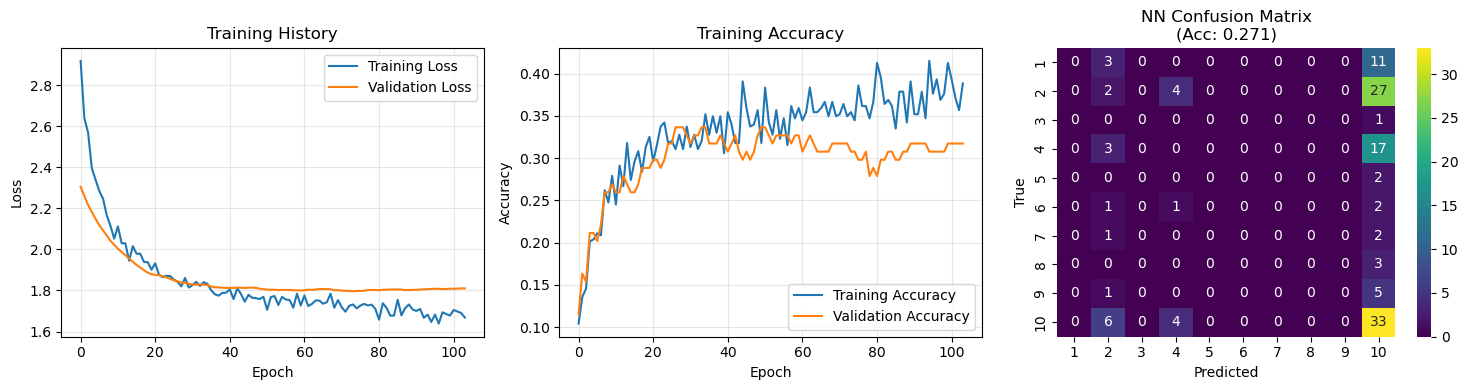

In [16]:
from tensorflow import keras
from tensorflow.keras import layers

# Prepare data for neural network
X = features_data.drop('nuclearity', axis=1).values
y = features_data['nuclearity'].values

print(f"Neural network input: {X.shape[1]} CSD PDF features")
print(f"Classes: {sorted(np.unique(y))}")

num_classes = len(np.unique(y))
y_categorical = keras.utils.to_categorical(y - 1, num_classes)

X_train, X_test, y_train, y_test, y_cat_train, y_cat_test = train_test_split(
    X, y, y_categorical, test_size=test_size, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Build smaller neural network for smaller dataset
print("\nBuilding neural network for CSD nuclearity classification...")

model = keras.Sequential([
    layers.Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.4),  # Higher dropout for smaller dataset
    
    layers.Dense(32, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.2),
    
    layers.Dense(num_classes, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Model architecture:")
model.summary()

callbacks = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=15, min_lr=1e-6)
]

print("\nTraining neural network...")
history = model.fit(
    X_train_scaled, y_cat_train,
    batch_size=min(32, len(X_train_scaled) // 4),  # Smaller batch size
    epochs=200,  # More epochs with early stopping
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

y_pred_prob = model.predict(X_test_scaled)
y_pred_classes = np.argmax(y_pred_prob, axis=1) + 1

accuracy_nn = accuracy_score(y_test, y_pred_classes)
f1_weighted_nn = f1_score(y_test, y_pred_classes, average='weighted', zero_division=0)
f1_macro_nn = f1_score(y_test, y_pred_classes, average='macro', zero_division=0)

print(f"\nNeural Network Results (CSD):")
print(f"Accuracy: {accuracy_nn:.3f}")
print(f"F1-score (weighted): {f1_weighted_nn:.3f}")
print(f"F1-score (macro): {f1_macro_nn:.3f}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Training history
axes[0].plot(history.history['loss'], label='Training Loss')
axes[0].plot(history.history['val_loss'], label='Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training History')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['accuracy'], label='Training Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Confusion matrix
conf_matrix_nn = confusion_matrix(y_test, y_pred_classes)
sns.heatmap(conf_matrix_nn, annot=True, fmt='d', cmap='viridis', ax=axes[2],
            xticklabels=sorted(np.unique(y)), yticklabels=sorted(np.unique(y)))
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('True')
axes[2].set_title(f'NN Confusion Matrix\n(Acc: {accuracy_nn:.3f})')

plt.tight_layout()
plt.show()

## Final Performance Comparison: CSD PDF Features

In [17]:
# ============================================================================
# FINAL ALGORITHM COMPARISON - CSD PDF FEATURES
# ============================================================================
print(f"\n" + "="*70)
print("FINAL ALGORITHM PERFORMANCE COMPARISON (CSD PDF Features)")
print("="*70)
print(f"{'Algorithm':<35} {'Accuracy':<12} {'F1-Weighted':<12}")
print("-"*70)
print(f"{'Neural Network':<35} {accuracy_nn:.3f}        {f1_weighted_nn:.3f}")
print(f"{'Gradient Boosting':<35} {accuracy:.3f}        {f1_weighted:.3f}")
print(f"{'Random Forest':<35} {accuracy_rf:.3f}        {f1_weighted_rf:.3f}")
print(f"{'LogReg + Polynomial':<35} {accuracy_lr_poly:.3f}        {f1_lr_poly:.3f}")
print(f"{'Naive Bayes':<35} {accuracy_nb_improved:.3f}        {f1_nb_improved:.3f}")
print(f"{'Tuned Logistic Regression':<35} {accuracy_lr_improved:.3f}        {f1_lr_improved:.3f}")
print("="*70)

# Identify best performing algorithms
algorithms = ['Gradient Boosting', 'Random Forest', 'Naive Bayes', 
              'Tuned LogReg', 'LogReg+Poly', 'Neural Network']
accuracies = [accuracy, accuracy_rf, accuracy_nb_improved, 
              accuracy_lr_improved, accuracy_lr_poly, accuracy_nn]
f1_scores = [f1_weighted, f1_weighted_rf, f1_nb_improved, 
             f1_lr_improved, f1_lr_poly, f1_weighted_nn]

best_acc_idx = np.argmax(accuracies)
best_f1_idx = np.argmax(f1_scores)

print(f"\nBest Accuracy: {algorithms[best_acc_idx]} ({accuracies[best_acc_idx]:.3f})")
print(f"Best F1-Score: {algorithms[best_f1_idx]} ({f1_scores[best_f1_idx]:.3f})")

print("\n" + "="*70)
print("Analysis complete! Results saved to:", csd_features_dir)


FINAL ALGORITHM PERFORMANCE COMPARISON (CSD PDF Features)
Algorithm                           Accuracy     F1-Weighted 
----------------------------------------------------------------------
Neural Network                      0.271        0.171
Gradient Boosting                   0.217        0.210
Random Forest                       0.209        0.196
LogReg + Polynomial                 0.295        0.217
Naive Bayes                         0.078        0.113
Tuned Logistic Regression           0.295        0.225

Best Accuracy: Tuned LogReg (0.295)
Best F1-Score: Tuned LogReg (0.225)

Analysis complete! Results saved to: /Users/dimitrygrebenyuk/Documents/GitHub/PDF-NN/complete workflow/pdf-nn-data/csd_structures/pdf_features
